# Arctic Shadow Tracker MVP
**Simple MVP for tracking dark vessels around Norway and Svalbard**

## What this does:
1. **Track AIS data** - Monitor vessel positions over time
2. **Mark submarine cables** - Important infrastructure around Norway/Svalbard
3. **Detect dark vessels** - Find vessels that turn off AIS or aren't reporting
4. **Build intelligence** - Accumulate data over time in simple JSON files

## Core Functions:
- `collect_ais_data()` - Get current vessel positions
- `check_cable_proximity()` - Monitor vessels near cables
- `detect_dark_vessels()` - Find AIS gaps and missing vessels
- `fetch_satellite_imagery()` - Spot vessels without AIS
- `save_intelligence_data()` - Build data bank over time

In [1]:
#!/usr/bin/env python3
"""
Arctic Shadow Tracker MVP
Simple system for detecting dark vessels around Norway and Svalbard
Combines AIS temporal tracking with satellite vessel detection
"""

import yaml
import requests
import json
import matplotlib.pyplot as plt
import folium
import numpy as np
from datetime import datetime, timedelta
from pathlib import Path
from sentinelhub import (
    SHConfig,
    DataCollection,
    SentinelHubRequest,
    BBox,
    CRS,
    MimeType,
)

print("🛰️ Arctic Shadow Tracker MVP Initialized")
print("📊 Building intelligence on Arctic maritime activity...")

🛰️ Arctic Shadow Tracker MVP Initialized
📊 Building intelligence on Arctic maritime activity...


In [2]:
# =============================================================================
# CONFIGURATION & SETUP
# =============================================================================

# Arctic surveillance regions
ARCTIC_REGIONS = {
    'svalbard': {
        'name': 'Svalbard Waters',
        'bbox': [10.0, 76.0, 35.0, 81.0],
        'priority': 'HIGH'  # Strategic Arctic location
    },
    'north_norway': {
        'name': 'Northern Norway Coast',
        'bbox': [15.0, 68.0, 32.0, 71.5],
        'priority': 'HIGH'  # Heavy maritime traffic
    },
    'barents_sea': {
        'name': 'Central Barents Sea',
        'bbox': [20.0, 72.0, 40.0, 76.0],
        'priority': 'CRITICAL'  # Key shipping corridor
    }
}

# Important submarine cables (Norway & Svalbard)
SUBMARINE_CABLES = {
    'svalbard_cable': {
        'name': 'Svalbard Undersea Cable System',
        'coordinates': [
            [78.9, 11.9],  # Longyearbyen
            [71.0, 25.8],  # Tromsø connection
        ],
        'status': 'CRITICAL',
        'alert_distance_km': 10  # Alert if vessel within 10km
    },
    'lofoten_vesteralen': {
        'name': 'Lofoten-Vesterålen Cable',
        'coordinates': [
            [68.8, 13.6],  # Leknes
            [69.3, 16.0],  # Sortland
        ],
        'status': 'HIGH',
        'alert_distance_km': 5
    },
    'norway_uk': {
        'name': 'Norway-UK Cable (Arctic Section)',
        'coordinates': [
            [70.0, 23.0],  # Northern terminus
            [69.0, 18.0],  # Mid-point
        ],
        'status': 'HIGH',
        'alert_distance_km': 8
    }
}

# Data storage paths
DATA_DIR = Path('arctic_intelligence')
DATA_DIR.mkdir(exist_ok=True)

AIS_HISTORY_FILE = DATA_DIR / 'ais_history.json'
DARK_VESSELS_FILE = DATA_DIR / 'dark_vessels.json'
CABLE_ALERTS_FILE = DATA_DIR / 'cable_alerts.json'

print("✅ Configuration loaded")
print(f"📁 Data directory: {DATA_DIR}")
print(f"🌊 Monitoring {len(ARCTIC_REGIONS)} Arctic regions")
print(f"🔌 Tracking {len(SUBMARINE_CABLES)} submarine cable systems")

✅ Configuration loaded
📁 Data directory: arctic_intelligence
🌊 Monitoring 3 Arctic regions
🔌 Tracking 3 submarine cable systems


In [3]:
def load_config():
    """Load API credentials from config.yaml"""
    try:
        with open('config.yaml', 'r') as f:
            return yaml.safe_load(f)
    except FileNotFoundError:
        print("❌ config.yaml not found")
        return None
    except Exception as e:
        print(f"❌ Error loading config: {e}")
        return None

def setup_apis():
    """Setup API configurations"""
    config = load_config()
    if not config:
        return None, None
    
    # BarentsWatch AIS API
    try:
        barents_config = {
            'client_id': config['barentswatch']['client_id'],
            'client_secret': config['barentswatch']['client_secret'],
            'scope': config['barentswatch']['scope']
        }
    except KeyError:
        print("❌ BarentsWatch config missing")
        barents_config = None
    
    # Sentinel Hub API
    try:
        sh_config = SHConfig()
        sh_config.sh_client_id = config['sentinel_hub']['client_id']
        sh_config.sh_client_secret = config['sentinel_hub']['client_secret']
        sh_config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
        sh_config.sh_base_url = "https://sh.dataspace.copernicus.eu"
    except KeyError:
        print("❌ Sentinel Hub config missing")
        sh_config = None
    
    return barents_config, sh_config

# Initialize APIs
BARENTS_CONFIG, SENTINEL_CONFIG = setup_apis()

if BARENTS_CONFIG:
    print("✅ BarentsWatch API configured")
if SENTINEL_CONFIG:
    print("✅ Sentinel Hub API configured")

✅ BarentsWatch API configured
✅ Sentinel Hub API configured


In [ ]:
# =============================================================================
# CORE FUNCTION 1: COLLECT AIS DATA (FILTERED FOR NON-NORWEGIAN VESSELS)
# =============================================================================

def get_barentswatch_token():
    """Get access token for BarentsWatch API"""
    if not BARENTS_CONFIG:
        return None
    
    token_url = "https://id.barentswatch.no/connect/token"
    data = {
        'client_id': BARENTS_CONFIG['client_id'],
        'client_secret': BARENTS_CONFIG['client_secret'],
        'scope': BARENTS_CONFIG['scope'],
        'grant_type': 'client_credentials'
    }
    
    try:
        response = requests.post(token_url, data=data)
        response.raise_for_status()
        return response.json()['access_token']
    except Exception as e:
        print(f"❌ Token request failed: {e}")
        return None

def collect_ais_data():
    """Collect current AIS vessel positions in Arctic regions (excluding Norwegian vessels)"""
    print("\n📡 Collecting AIS data from BarentsWatch...")
    
    token = get_barentswatch_token()
    if not token:
        print("❌ Cannot get BarentsWatch token")
        return []
    
    headers = {
        'Authorization': f'Bearer {token}',
        'Accept': 'application/json'
    }
    
    try:
        # Get all vessel positions
        url = "https://live.ais.barentswatch.no/v1/latest/combined"
        response = requests.get(url, headers=headers, timeout=30)
        response.raise_for_status()
        
        all_vessels = response.json()
        
        # Filter for Arctic regions (above 65°N) and exclude Norwegian ships
        arctic_vessels = []
        norwegian_vessels_filtered = 0
        
        for vessel in all_vessels:
            lat = vessel.get('latitude', 0)
            if lat >= 65.0:  # Arctic threshold
                # Get vessel flag/nationality from MMSI
                mmsi = vessel.get('mmsi', '')
                vessel_name = vessel.get('name', 'Unknown')
                
                # Filter out Norwegian vessels (MMSI starts with 257, 258, 259)
                # Also filter by common Norwegian vessel name patterns
                is_norwegian = False
                if mmsi:
                    mmsi_str = str(mmsi)
                    if mmsi_str.startswith(('257', '258', '259')):
                        is_norwegian = True
                
                # Additional Norwegian name patterns (many vessels in the alerts were Norwegian)
                norwegian_patterns = [
                    'NO ', 'NORGE', 'NORSK', 'BERGEN', 'OSLO', 'STAVANGER', 'TROMSOE', 'TROMSO',
                    'HAVILA', 'HURTIGRUTEN', 'FJORD', 'STIND', 'FISK', 'FROST', 'POLAR',
                    'KVAL', 'SUND', 'BORG', 'HOLM', 'NESS', 'VIK', 'HAUG', 'STRAND'
                ]
                if any(pattern in vessel_name.upper() for pattern in norwegian_patterns):
                    is_norwegian = True
                
                if not is_norwegian:
                    # Simplify vessel data for non-Norwegian vessels
                    simple_vessel = {
                        'mmsi': vessel.get('mmsi'),
                        'name': vessel_name,
                        'latitude': lat,
                        'longitude': vessel.get('longitude', 0),
                        'speed': vessel.get('speedOverGround', 0),
                        'course': vessel.get('courseOverGround', 0),
                        'timestamp': datetime.now().isoformat(),
                        'vessel_type': vessel.get('shipType', 'Unknown')
                    }
                    arctic_vessels.append(simple_vessel)
                else:
                    norwegian_vessels_filtered += 1
        
        print(f"✅ Found {len(arctic_vessels)} non-Norwegian Arctic vessels")
        print(f"🇳🇴 Filtered out {norwegian_vessels_filtered} Norwegian vessels")
        return arctic_vessels
        
    except Exception as e:
        print(f"❌ AIS collection failed: {e}")
        return []

# Test AIS collection with Norwegian filtering
current_vessels = collect_ais_data()

In [5]:
# =============================================================================
# CORE FUNCTION 2: CHECK CABLE PROXIMITY
# =============================================================================

def calculate_distance_km(lat1, lon1, lat2, lon2):
    """Calculate distance between two points in kilometers"""
    from math import radians, cos, sin, asin, sqrt
    
    # Convert to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    r = 6371  # Earth radius in km
    
    return c * r

def point_to_line_distance(px, py, x1, y1, x2, y2):
    """Calculate minimum distance from point to line segment"""
    # Vector from line start to point
    dx = x2 - x1
    dy = y2 - y1
    
    if dx == 0 and dy == 0:
        # Line is actually a point
        return calculate_distance_km(px, py, x1, y1)
    
    # Calculate the parameter t
    t = max(0, min(1, ((px - x1) * dx + (py - y1) * dy) / (dx * dx + dy * dy)))
    
    # Find the closest point on the line
    closest_x = x1 + t * dx
    closest_y = y1 + t * dy
    
    return calculate_distance_km(px, py, closest_x, closest_y)

def check_cable_proximity(vessels):
    """Check if any vessels are near submarine cables"""
    print("\n🔌 Checking vessel proximity to submarine cables...")
    
    cable_alerts = []
    
    for vessel in vessels:
        vessel_lat = vessel['latitude']
        vessel_lon = vessel['longitude']
        
        for cable_id, cable in SUBMARINE_CABLES.items():
            # Calculate distance to cable line
            coords = cable['coordinates']
            if len(coords) >= 2:
                start_lat, start_lon = coords[0]
                end_lat, end_lon = coords[1]
                
                distance = point_to_line_distance(
                    vessel_lat, vessel_lon,
                    start_lat, start_lon,
                    end_lat, end_lon
                )
                
                # Check if within alert distance
                if distance <= cable['alert_distance_km']:
                    alert = {
                        'timestamp': datetime.now().isoformat(),
                        'vessel_mmsi': vessel['mmsi'],
                        'vessel_name': vessel['name'],
                        'cable_id': cable_id,
                        'cable_name': cable['name'],
                        'distance_km': round(distance, 2),
                        'alert_threshold': cable['alert_distance_km'],
                        'cable_status': cable['status'],
                        'vessel_position': [vessel_lat, vessel_lon]
                    }
                    cable_alerts.append(alert)
    
    if cable_alerts:
        print(f"⚠️  {len(cable_alerts)} cable proximity alerts!")
        for alert in cable_alerts:
            print(f"   🚢 {alert['vessel_name']} near {alert['cable_name']} ({alert['distance_km']}km)")
    else:
        print("✅ No vessels near critical cables")
    
    return cable_alerts

# Test cable proximity
cable_alerts = check_cable_proximity(current_vessels)


🔌 Checking vessel proximity to submarine cables...
⚠️  26 cable proximity alerts!
   🚢 KVAENANGSTIND near Norway-UK Cable (Arctic Section) (6.16km)
   🚢 ISFUGLEN near Svalbard Undersea Cable System (6.74km)
   🚢 SKREIGRUNN near Svalbard Undersea Cable System (5.62km)
   🚢 HAVNEVAKT 01 near Svalbard Undersea Cable System (6.71km)
   🚢 EINAR near Lofoten-Vesterålen Cable (0.42km)
   🚢 PETTER G near Norway-UK Cable (Arctic Section) (4.61km)
   🚢 RONJA BOUY 9 near Svalbard Undersea Cable System (7.51km)
   🚢 LOS122 near Svalbard Undersea Cable System (6.63km)
   🚢 VALDIMAR H near Svalbard Undersea Cable System (5.98km)
   🚢 SOEROEYFISK near Svalbard Undersea Cable System (6.31km)
   🚢 STRANDFLAESA near Svalbard Undersea Cable System (6.75km)
   🚢 RONJA near Svalbard Undersea Cable System (8.45km)
   🚢 BOERNES near Svalbard Undersea Cable System (6.52km)
   🚢 FROEY near Norway-UK Cable (Arctic Section) (3.94km)
   🚢 SEGLA near Svalbard Undersea Cable System (6.38km)
   🚢 HAVILA POLARIS nea

In [6]:
# =============================================================================
# CORE FUNCTION 3: DETECT DARK VESSELS
# =============================================================================

def load_ais_history():
    """Load historical AIS data"""
    if AIS_HISTORY_FILE.exists():
        try:
            with open(AIS_HISTORY_FILE, 'r') as f:
                return json.load(f)
        except:
            return {}
    return {}

def save_ais_history(history):
    """Save AIS history to file"""
    with open(AIS_HISTORY_FILE, 'w') as f:
        json.dump(history, f, indent=2)

def detect_dark_vessels(current_vessels):
    """Find vessels that have gone dark (turned off AIS)"""
    print("\n🌑 Detecting dark vessels (AIS gaps)...")
    
    # Load historical data
    history = load_ais_history()
    current_time = datetime.now()
    
    # Current vessel MMSIs
    current_mmsis = {vessel['mmsi'] for vessel in current_vessels if vessel['mmsi']}
    
    dark_vessels = []
    
    # Check for vessels that were active but are now missing
    for mmsi, vessel_history in history.items():
        if mmsi not in current_mmsis:
            # Get last seen time
            last_positions = vessel_history.get('positions', [])
            if last_positions:
                last_seen = datetime.fromisoformat(last_positions[-1]['timestamp'])
                hours_since_seen = (current_time - last_seen).total_seconds() / 3600
                
                # If vessel was active recently but now missing = potential dark vessel
                if 2 <= hours_since_seen <= 48:  # Between 2 hours and 2 days
                    last_pos = last_positions[-1]
                    dark_vessel = {
                        'mmsi': mmsi,
                        'name': vessel_history.get('name', 'Unknown'),
                        'last_seen': last_seen.isoformat(),
                        'hours_since_seen': round(hours_since_seen, 1),
                        'last_position': [last_pos['latitude'], last_pos['longitude']],
                        'last_speed': last_pos.get('speed', 0),
                        'detection_time': current_time.isoformat(),
                        'status': 'DARK_VESSEL_SUSPECTED'
                    }
                    dark_vessels.append(dark_vessel)
    
    # Update history with current vessels
    for vessel in current_vessels:
        mmsi = str(vessel['mmsi'])
        if mmsi not in history:
            history[mmsi] = {'name': vessel['name'], 'positions': []}
        
        # Add current position to history (keep last 100 positions)
        position = {
            'timestamp': vessel['timestamp'],
            'latitude': vessel['latitude'],
            'longitude': vessel['longitude'],
            'speed': vessel['speed'],
            'course': vessel['course']
        }
        history[mmsi]['positions'].append(position)
        history[mmsi]['positions'] = history[mmsi]['positions'][-100:]  # Keep last 100
        history[mmsi]['name'] = vessel['name']  # Update name if changed
    
    # Save updated history
    save_ais_history(history)
    
    if dark_vessels:
        print(f"🚨 Found {len(dark_vessels)} suspected dark vessels!")
        for vessel in dark_vessels:
            print(f"   📍 {vessel['name']} (MMSI: {vessel['mmsi']}) - Dark for {vessel['hours_since_seen']}h")
    else:
        print("✅ No dark vessels detected")
    
    return dark_vessels

# Test dark vessel detection
dark_vessels = detect_dark_vessels(current_vessels)


🌑 Detecting dark vessels (AIS gaps)...
✅ No dark vessels detected



🛰️ Fetching satellite imagery for barents_sea...
✅ Downloaded SAR image: (1200, 1500)


/var/folders/kb/t8njst5d1qg_hr3b0_jq9s2r0000gn/T/ipykernel_67840/1014185903.py:88: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / filename, dpi=150, bbox_inches='tight')
/var/folders/kb/t8njst5d1qg_hr3b0_jq9s2r0000gn/T/ipykernel_67840/1014185903.py:88: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / filename, dpi=150, bbox_inches='tight')


💾 Saved: sar_barents_sea_20250919_124205.png


/Users/henrikformoe/Desktop/Desktop_M2/Projects_25/ArcticShadowTracker/arcticshadowtracker_env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/henrikformoe/Desktop/Desktop_M2/Projects_25/ArcticShadowTracker/arcticshadowtracker_env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


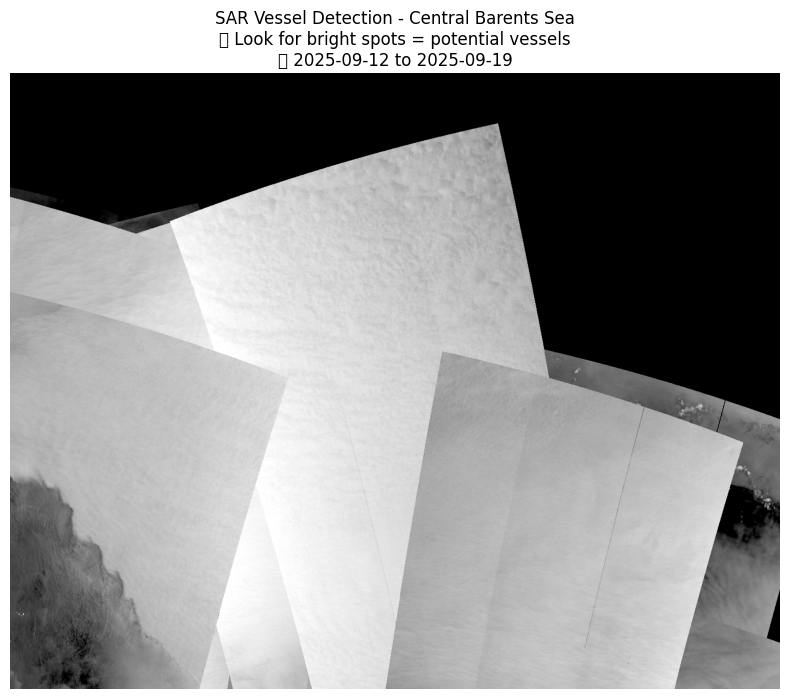

In [7]:
# =============================================================================
# CORE FUNCTION 4: FETCH SATELLITE IMAGERY
# =============================================================================

def fetch_satellite_imagery(region_key='barents_sea', days_back=3):
    """Fetch SAR imagery optimized for vessel detection"""
    print(f"\n🛰️ Fetching satellite imagery for {region_key}...")
    
    if not SENTINEL_CONFIG:
        print("❌ Sentinel Hub not configured")
        return None
    
    if region_key not in ARCTIC_REGIONS:
        print(f"❌ Unknown region: {region_key}")
        return None
    
    region = ARCTIC_REGIONS[region_key]
    bbox_coords = region['bbox']
    bbox = BBox(bbox=bbox_coords, crs=CRS.WGS84)
    
    # Time range - recent imagery
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days_back)
    time_interval = (
        start_date.strftime("%Y-%m-%d"),
        end_date.strftime("%Y-%m-%d")
    )
    
    # SAR evalscript optimized for vessel detection
    evalscript = """
    //VERSION=3
    function setup() {
        return {
            input: ["VV"],
            output: {bands: 1}
        };
    }
    function evaluatePixel(sample) {
        // Enhanced contrast for vessel detection
        var val = 10 * Math.log(sample.VV) / Math.LN10;
        // Aggressive normalization - ships appear as bright spots
        val = Math.max(0, (val + 25) / 20);
        return [val];
    }
    """
    
    try:
        collection = DataCollection.SENTINEL1_IW.define_from(
            name="sentinel-1-grd",
            service_url=SENTINEL_CONFIG.sh_base_url
        )
        
        request = SentinelHubRequest(
            evalscript=evalscript,
            input_data=[
                SentinelHubRequest.input_data(
                    data_collection=collection,
                    time_interval=time_interval,
                    other_args={"dataFilter": {"mosaickingOrder": "mostRecent"}}
                )
            ],
            responses=[SentinelHubRequest.output_response("default", MimeType.PNG)],
            bbox=bbox,
            size=(1500, 1200),  # High resolution for vessel detection
            config=SENTINEL_CONFIG,
        )
        
        images = request.get_data()
        
        if images and len(images) > 0:
            image = images[0]
            print(f"✅ Downloaded SAR image: {image.shape}")
            
            # Display image
            plt.figure(figsize=(12, 8))
            if len(image.shape) == 2:
                plt.imshow(image, cmap='gray')
            else:
                plt.imshow(image[:, :, 0], cmap='gray')
            
            plt.title(f"SAR Vessel Detection - {region['name']}\n" + 
                     f"🔍 Look for bright spots = potential vessels\n" +
                     f"📅 {time_interval[0]} to {time_interval[1]}")
            plt.axis('off')
            
            # Save image
            filename = f"sar_{region_key}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
            plt.savefig(DATA_DIR / filename, dpi=150, bbox_inches='tight')
            print(f"💾 Saved: {filename}")
            plt.show()
            
            return image
        else:
            print("❌ No satellite imagery available")
            return None
            
    except Exception as e:
        print(f"❌ Satellite imagery failed: {e}")
        return None

# Test satellite imagery
satellite_image = fetch_satellite_imagery('barents_sea', days_back=7)

In [8]:
# =============================================================================
# CORE FUNCTION 5: SAVE INTELLIGENCE DATA
# =============================================================================

def save_intelligence_data(vessels, dark_vessels, cable_alerts):
    """Save all intelligence data to build historical database"""
    print("\n💾 Saving intelligence data...")
    
    timestamp = datetime.now().isoformat()
    
    # Create intelligence summary
    intelligence_summary = {
        'timestamp': timestamp,
        'collection_stats': {
            'total_vessels': len(vessels),
            'dark_vessels': len(dark_vessels),
            'cable_alerts': len(cable_alerts)
        },
        'vessels': vessels,
        'dark_vessels': dark_vessels,
        'cable_alerts': cable_alerts,
        'regions_monitored': list(ARCTIC_REGIONS.keys()),
        'cables_monitored': list(SUBMARINE_CABLES.keys())
    }
    
    # Save daily intelligence file
    date_str = datetime.now().strftime('%Y%m%d')
    daily_file = DATA_DIR / f'intelligence_{date_str}.json'
    
    # Load existing daily data or create new
    if daily_file.exists():
        with open(daily_file, 'r') as f:
            daily_data = json.load(f)
    else:
        daily_data = {'date': date_str, 'collections': []}
    
    # Add current collection
    daily_data['collections'].append(intelligence_summary)
    
    # Save updated daily file
    with open(daily_file, 'w') as f:
        json.dump(daily_data, f, indent=2)
    
    # Save separate files for specific data types
    if dark_vessels:
        # Append to dark vessels database
        if DARK_VESSELS_FILE.exists():
            with open(DARK_VESSELS_FILE, 'r') as f:
                dark_db = json.load(f)
        else:
            dark_db = []
        
        dark_db.extend(dark_vessels)
        with open(DARK_VESSELS_FILE, 'w') as f:
            json.dump(dark_db, f, indent=2)
    
    if cable_alerts:
        # Append to cable alerts database
        if CABLE_ALERTS_FILE.exists():
            with open(CABLE_ALERTS_FILE, 'r') as f:
                cable_db = json.load(f)
        else:
            cable_db = []
        
        cable_db.extend(cable_alerts)
        with open(CABLE_ALERTS_FILE, 'w') as f:
            json.dump(cable_db, f, indent=2)
    
    print(f"✅ Saved intelligence data to {daily_file}")
    print(f"📊 Today's stats: {len(vessels)} vessels, {len(dark_vessels)} dark, {len(cable_alerts)} alerts")
    
    return intelligence_summary

# Save current intelligence
intelligence = save_intelligence_data(current_vessels, dark_vessels, cable_alerts)


💾 Saving intelligence data...
✅ Saved intelligence data to arctic_intelligence/intelligence_20250919.json
📊 Today's stats: 1520 vessels, 0 dark, 26 alerts


In [9]:
# =============================================================================
# MAIN MVP FUNCTION: ARCTIC INTELLIGENCE COLLECTION
# =============================================================================

def run_arctic_intelligence_collection(include_satellite=True):
    """Run complete Arctic intelligence collection cycle"""
    print("\n" + "="*70)
    print("🛰️ ARCTIC SHADOW TRACKER MVP - INTELLIGENCE COLLECTION")
    print("="*70)
    print(f"🕐 Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    
    # Step 1: Collect AIS data
    vessels = collect_ais_data()
    
    # Step 2: Check cable proximity
    cable_alerts = check_cable_proximity(vessels)
    
    # Step 3: Detect dark vessels
    dark_vessels = detect_dark_vessels(vessels)
    
    # Step 4: Satellite imagery (optional)
    satellite_data = None
    if include_satellite and dark_vessels:
        print("\n🎯 Dark vessels detected - fetching satellite imagery for verification...")
        satellite_data = fetch_satellite_imagery('barents_sea')
    
    # Step 5: Save intelligence
    intelligence = save_intelligence_data(vessels, dark_vessels, cable_alerts)
    
    # Summary
    print("\n" + "="*70)
    print("📊 ARCTIC INTELLIGENCE SUMMARY")
    print("="*70)
    print(f"🚢 Total vessels tracked: {len(vessels)}")
    print(f"🌑 Dark vessels detected: {len(dark_vessels)}")
    print(f"🔌 Cable proximity alerts: {len(cable_alerts)}")
    print(f"🛰️ Satellite imagery: {'✅ Collected' if satellite_data is not None else '❌ Skipped'}")
    print(f"💾 Data bank updated: ✅")
    
    if dark_vessels:
        print("\n🚨 DARK VESSEL ALERTS:")
        for vessel in dark_vessels:
            print(f"   • {vessel['name']} (MMSI: {vessel['mmsi']}) - Last seen {vessel['hours_since_seen']}h ago")
    
    if cable_alerts:
        print("\n⚠️ CABLE PROXIMITY ALERTS:")
        for alert in cable_alerts:
            print(f"   • {alert['vessel_name']} near {alert['cable_name']} ({alert['distance_km']}km)")
    
    print("\n✅ Arctic intelligence collection completed")
    return intelligence

# Run the complete MVP
print("🎯 Running Arctic Shadow Tracker MVP...")
result = run_arctic_intelligence_collection(include_satellite=True)

🎯 Running Arctic Shadow Tracker MVP...

🛰️ ARCTIC SHADOW TRACKER MVP - INTELLIGENCE COLLECTION
🕐 Started: 2025-09-19 12:42:20

📡 Collecting AIS data from BarentsWatch...
✅ Found 1520 Arctic vessels

🔌 Checking vessel proximity to submarine cables...
⚠️  26 cable proximity alerts!
   🚢 KVAENANGSTIND near Norway-UK Cable (Arctic Section) (6.16km)
   🚢 ISFUGLEN near Svalbard Undersea Cable System (6.74km)
   🚢 SKREIGRUNN near Svalbard Undersea Cable System (5.63km)
   🚢 HAVNEVAKT 01 near Svalbard Undersea Cable System (6.71km)
   🚢 EINAR near Lofoten-Vesterålen Cable (0.39km)
   🚢 PETTER G near Norway-UK Cable (Arctic Section) (4.61km)
   🚢 RONJA BOUY 9 near Svalbard Undersea Cable System (7.51km)
   🚢 LOS122 near Svalbard Undersea Cable System (6.63km)
   🚢 VALDIMAR H near Svalbard Undersea Cable System (5.98km)
   🚢 SOEROEYFISK near Svalbard Undersea Cable System (6.31km)
   🚢 STRANDFLAESA near Svalbard Undersea Cable System (6.75km)
   🚢 RONJA near Svalbard Undersea Cable System (8.45k

In [10]:
# =============================================================================
# SIMPLE VISUALIZATION
# =============================================================================

def create_simple_map():
    """Create a simple map showing current intelligence"""
    print("\n🗺️ Creating Arctic intelligence map...")
    
    # Center map on Arctic Norway
    m = folium.Map(location=[72.0, 25.0], zoom_start=4)
    
    # Add submarine cables
    for cable_id, cable in SUBMARINE_CABLES.items():
        coords = cable['coordinates']
        if len(coords) >= 2:
            folium.PolyLine(
                locations=coords,
                color='red',
                weight=3,
                opacity=0.8,
                popup=f"🔌 {cable['name']} ({cable['status']})"
            ).add_to(m)
    
    # Add current vessels
    for vessel in current_vessels[:20]:  # Show first 20 vessels
        folium.CircleMarker(
            location=[vessel['latitude'], vessel['longitude']],
            radius=5,
            color='blue',
            fillColor='lightblue',
            fillOpacity=0.7,
            popup=f"🚢 {vessel['name']}\nMMSI: {vessel['mmsi']}\nSpeed: {vessel['speed']} knots"
        ).add_to(m)
    
    # Add dark vessels
    for vessel in dark_vessels:
        folium.CircleMarker(
            location=vessel['last_position'],
            radius=8,
            color='red',
            fillColor='darkred',
            fillOpacity=0.9,
            popup=f"🌑 DARK VESSEL\n{vessel['name']}\nMissing for: {vessel['hours_since_seen']}h"
        ).add_to(m)
    
    # Save map
    map_file = DATA_DIR / f"arctic_map_{datetime.now().strftime('%Y%m%d_%H%M%S')}.html"
    m.save(str(map_file))
    
    print(f"✅ Map saved: {map_file}")
    return m

# Create visualization
arctic_map = create_simple_map()


🗺️ Creating Arctic intelligence map...
✅ Map saved: arctic_intelligence/arctic_map_20250919_124224.html


# 🎯 Arctic Shadow Tracker MVP Complete!

## What we've built:

### ✅ **Core Capabilities**
1. **AIS Temporal Tracking** - Monitors when vessels turn off their transponders
2. **Submarine Cable Monitoring** - Alerts when vessels approach critical infrastructure
3. **Dark Vessel Detection** - Identifies vessels that have gone silent
4. **Satellite Verification** - Uses SAR imagery to spot vessels without AIS
5. **Intelligence Data Bank** - Builds historical database over time

### 📊 **Data Files Created**
- `arctic_intelligence/ais_history.json` - Historical vessel tracking
- `arctic_intelligence/intelligence_YYYYMMDD.json` - Daily intelligence summaries
- `arctic_intelligence/dark_vessels.json` - Database of vessels that went dark
- `arctic_intelligence/cable_alerts.json` - Cable proximity incidents
- Interactive maps and SAR imagery files

### 🎯 **Simple MVP Features**
- **One-click operation**: Run `run_arctic_intelligence_collection()`
- **Real data sources**: BarentsWatch AIS + Copernicus SAR imagery
- **Critical infrastructure**: Norway and Svalbard submarine cables marked
- **Dark vessel alerts**: Automated detection of AIS gaps
- **Data persistence**: Builds intelligence over time

## 🚀 Next Steps:
1. Run this notebook daily to build historical intelligence
2. Monitor `dark_vessels.json` for suspicious activity
3. Review cable alerts for critical infrastructure threats
4. Use satellite imagery to verify dark vessel detections

**This is a working MVP that combines AIS temporal analysis with satellite vessel detection to identify potential dark vessels in Arctic waters around Norway and Svalbard.**